In [1]:
import os

# 在导入任何网络库之前清除代理设置
for var in [
    "HTTP_PROXY",
    "HTTPS_PROXY",
    "http_proxy",
    "https_proxy",
    "ALL_PROXY",
    "all_proxy",
]:
    os.environ.pop(var, None)

# 强制设置不代理本地地址
os.environ["NO_PROXY"] = "localhost,127.0.0.1"


In [2]:
from dotenv import load_dotenv

load_dotenv("./../.env")


True

In [3]:
from utils import agent_nodes, config
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict, Annotated, List
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

In [4]:
class RouterQuery(BaseModel):
    datasource: str = Field(
        description="Datasource to route query to: 'retrieve' for financial documents, 'sql_agent' for employee information, 'web_search' for general knowledge"
    )


In [5]:
class AgentState(TypedDict):
    messages:Annotated[list, operator.add]
    retrieved_docs: str
    rewritten_queries: List[str]

In [6]:
llm = config.get_llm(model=config.AGENT_LLM)
llm.invoke("Hello!")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b-cloud', 'created_at': '2026-03-13T08:57:07.766117702Z', 'done': True, 'done_reason': 'stop', 'total_duration': 517445136, 'load_duration': None, 'prompt_eval_count': 69, 'prompt_eval_duration': None, 'eval_count': 41, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b-cloud', 'model_provider': 'ollama'}, id='lc_run--019ce669-e084-7da2-ba13-93658fb47da1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 69, 'output_tokens': 41, 'total_tokens': 110})

In [7]:
# -----------------------------------------------------------------------------
# Query Analysis & Routing
# -----------------------------------------------------------------------------

# Route query to appropriate datasource
def route_question(state: AgentState):

    query = agent_nodes.get_latest_user_query(state["messages"])

    print(f"[QUERY] {query}")

    llm_router = llm.with_structured_output(RouterQuery)

    system_prompt = """You are an expert at routing user questions to the appropriate datasource.

                    **Datasources:**
                    1. **retrieve**: Financial documents (10-K, 10-Q, 8-K reports) about companies like Amazon, Apple, Google
                    - Questions about: revenue, operating income, cash flow, segments, financial metrics, quarterly/annual performance
                    - Examples: "What was Amazon's revenue in 2023?", "Compare Apple vs Google Q1 2024 revenue"

                    2. **sql_agent**: Employee database with structured data
                    - Questions about: employees, departments, salaries, managers, job titles, hiring dates
                    - Examples: "Who is the CFO?", "List employees in Finance", "What is John's salary?"

                    3. **web_search**: General knowledge outside our databases
                    - Questions about: current events, general facts, topics unrelated to our data
                    - Examples: "What is inflation rate?", "How does RAG work?", "Capital of France?"

                    **Decision Logic:**
                    - Check for financial terms (revenue, income, cash flow, quarterly, annual, 10-K, 10-Q) -> retrieve
                    - Check for company names in our database (amazon, apple, google) -> retrieve
                    - Check for employee-related terms (employee, department, salary, CFO, manager) -> sql_agent
                    - Everything else -> web_search

                    You MUST respond with ONLY a JSON object, no other text:
                    {"datasource": "retrieve"}
                    or
                    {"datasource": "sql_agent"}
                    or
                    {"datasource": "web_search"}"""

    messages = [SystemMessage(system_prompt), HumanMessage(query)]
    response = llm_router.invoke(messages)

    datasource = response.datasource

    print(f"[DECISION] Routing to {datasource}")

    return datasource


In [8]:
route_question({"messages": [HumanMessage("what is the mean salary of whole employees?")]})

[QUERY] what is the mean salary of whole employees?
[DECISION] Routing to sql_agent


'sql_agent'

In [9]:
#### Add short term memory

from langgraph.checkpoint.sqlite import SqliteSaver
import os
import sqlite3

db_name = "db/checkpoints.db"

os.makedirs("db", exist_ok=True)


In [10]:
# Node Name
RETRIEVE = "retrieve"
GRADE_DOC = "grade_doc"
WEB_SEARCH = "web_search"
SQL_AGENT = "sql_agent"
GENERATE = "generate"
TRANS_QUERY = "trans_query"

In [11]:
def build_agent():
    builder = StateGraph(AgentState)

    builder.add_node(RETRIEVE, agent_nodes.retrieve_node)
    builder.add_node(GRADE_DOC, agent_nodes.generate_node)
    builder.add_node(TRANS_QUERY, agent_nodes.transform_query_node)
    builder.add_node(WEB_SEARCH, agent_nodes.web_search_node)
    builder.add_node(SQL_AGENT, agent_nodes.sql_agent_node)
    builder.add_node(GENERATE, agent_nodes.generate_node)

    builder.add_conditional_edges(START, route_question, [RETRIEVE, WEB_SEARCH, SQL_AGENT])
    builder.add_edge(RETRIEVE, GRADE_DOC)
    builder.add_conditional_edges(GRADE_DOC, agent_nodes.should_generate, [TRANS_QUERY, GENERATE])
    builder.add_edge(TRANS_QUERY, RETRIEVE)
    builder.add_conditional_edges(GENERATE, agent_nodes.check_answer_quality, [GENERATE, END, TRANS_QUERY])
    builder.add_edge(WEB_SEARCH, END)
    builder.add_edge(SQL_AGENT, END)

    conn = sqlite3.connect(db_name, check_same_thread=False)
    checkpointer = SqliteSaver(conn)
    graph = builder.compile(checkpointer=checkpointer)

    return graph


    

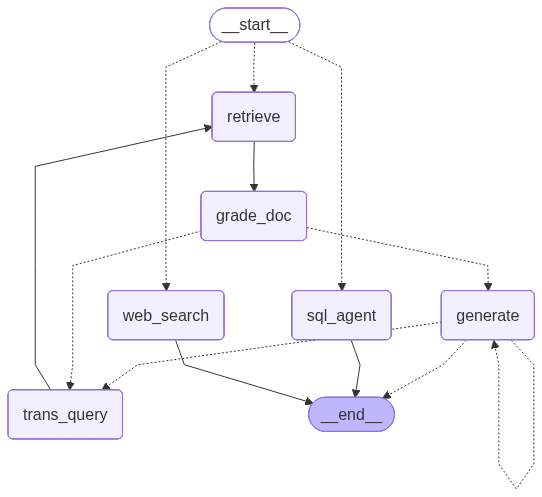

In [12]:
agent = build_agent()
agent

In [13]:
config = {"configurable": {"thread_id": "test2"}}

query = "show me amazon's revenue in 2023?"
result = agent.invoke({"messages": [HumanMessage(query)]}, config=config)

[QUERY] show me amazon's revenue in 2023?
[DECISION] Routing to retrieve
[RETRIEVE] fetching documents...
[RETRIEVE] Query 1: show me amazon's revenue in 2023?

[TOOL] retrieve_docs called
[QUERY] show me amazon's revenue in 2023?
keywords: {'company_name': 'amazon', 'fiscal_year': 2023}
references: ['revenue', 'net revenue', 'gross profit', 'operating income', 'consolidated statements of operations']
   [1] Doc 13: score=21.1137
   [2] Doc 1: score=20.5237
   [3] Doc 3: score=19.3038
[RETRIEVED] 3 documents
[GENERATE] Creating Answer
[ROUTER] Assess graded documents
[ROUTER] Have relevant documents - generating answer
[GENERATE] Creating Answer
[ROUTER] Generation is gounded in documents
[ROUTER] Checking answer quality
[ROUTER] generation is good. - USEFUL


In [15]:
query = "What is openclaw?"
result = agent.invoke({"messages": [HumanMessage(query)]}, config=config)

[QUERY] What is openclaw?
[DECISION] Routing to web_search
[WEB] Agent is completed!


In [17]:
query = "How many employees in the database?"
result = agent.invoke({"messages": [HumanMessage(query)]}, config=config)


[QUERY] How many employees in the database?
[DECISION] Routing to sql_agent
[TOOL] Generated SQL Query: SELECT COUNT(*) AS employee_co...
[TOOL] Your sql query is validated. Passed!
[SQL] Agent completed!


In [18]:
result["messages"][-1].pretty_print()

================================== Ai Message ==================================

**Number of employees in the database:** 300,024.
